# Patient Comfort and Healthcare Experience Analysis

## Research Statement

Patient comfort influences overall healthcare experience quality.

## Objective

The objective of this study is to analyze how different patient comfort factors, such as waiting time, hygiene, doctor communication, and hospital facilities, affect overall healthcare experience quality.

## Dependent Variable

- satisfaction in RM (Overall healthcare experience quality)

## Independent Variables

- Waiting time
- Hygiene and cleaning
- Doctor communication
- Diagnosis accuracy
- Hospital room quality
- Lab services
- Availability of drugs
- Parking and facilities
- Other comfort-related factors

This analysis includes:

1. Data Understanding
2. Data Cleaning
3. Descriptive Analysis
4. Correlation Analysis
5. Inferential Analysis
6. Predictive Analysis


## Import Required Libraries

This section imports the necessary libraries for data analysis, visualization, statistical testing, and machine learning.


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, kruskal
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

## Load Dataset

The dataset contains patient ratings related to comfort and service quality in healthcare facilities.


In [78]:
df = pd.read_csv("datasetsatisfaction.csv")

df.head()

,satisfaction in RM,Check up appointment,Time waiting,Admin procedures,Hygiene and cleaning,Time of appointment,Quality/experience dr.,Specialists avaliable,Communication with dr,Exact diagnosis,Modern equipment,friendly health care workers,lab services,avaliablity of drugs,waiting rooms,hospital rooms quality,"parking, playing rooms, caffes"
0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,2.0,2.0,1.0,2.0,1.0,2.0,2.0,1.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0
2,2.0,1.0,1.0,2.0,2.0,2.0,4.0,4.0,4.0,4.0,1.0,4.0,4.0,1.0,2.0,2.0,2.0
3,2.0,2.0,4.0,1.0,1.0,2.0,4.0,1.0,1.0,4.0,1.0,1.0,4.0,5.0,4.0,1.0,1.0
4,3.0,4.0,1.0,1.0,2.0,1.0,5.0,5.0,5.0,5.0,2.0,5.0,5.0,5.0,1.0,1.0,1.0


## Data Understanding

This section explores the structure of the dataset, including the number of records, variables, and data types.

In [79]:
print("Dataset Shape:", df.shape)



Dataset Shape: (453, 17)


In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 453 entries, 0 to 452
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   satisfaction in RM              452 non-null    float64
 1   Check up appointment            452 non-null    float64
 2   Time waiting                    452 non-null    float64
 3   Admin procedures                452 non-null    float64
 4   Hygiene and cleaning            452 non-null    float64
 5   Time of appointment             452 non-null    float64
 6   Quality/experience dr.          452 non-null    float64
 7   Specialists avaliable           452 non-null    float64
 8   Communication with dr           452 non-null    float64
 9   Exact diagnosis                 452 non-null    float64
 10  Modern equipment                452 non-null    float64
 11  friendly health care workers    452 non-null    float64
 12  lab services                    452 

In [81]:
df.describe()

,satisfaction in RM,Check up appointment,Time waiting,Admin procedures,Hygiene and cleaning,Time of appointment,Quality/experience dr.,Specialists avaliable,Communication with dr,Exact diagnosis,Modern equipment,friendly health care workers,lab services,avaliablity of drugs,waiting rooms,hospital rooms quality,"parking, playing rooms, caffes"
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000
mean,2.435841,2.626106,2.517699,2.595133,2.772124,2.575221,2.924779,2.674779,2.814159,2.829646,2.506637,2.829646,2.756637,2.745575,2.668142,2.714602,2.743363
std,0.526755,1.464897,1.407029,1.370346,1.264849,1.442499,1.522516,1.412011,1.443995,1.502314,1.300674,1.401522,1.470501,1.385498,1.242468,1.222646,1.157478
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,2.000000,2.000000
50%,2.000000,3.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.500000,3.000000,3.000000,2.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000
75%,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,4.000000,3.250000,3.000000,3.000000
max,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [82]:
df.columns

Index(['satisfaction in RM', 'Check up appointment', 'Time waiting',
       'Admin procedures', 'Hygiene and cleaning', 'Time of appointment',
       'Quality/experience dr.', 'Specialists avaliable',
       'Communication with dr', 'Exact diagnosis', 'Modern equipment',
       'friendly health care workers', 'lab services', 'avaliablity of drugs',
       'waiting rooms', 'hospital rooms quality',
       'parking, playing rooms, caffes'],
      dtype='object')

In [83]:
df.isnull().sum()

satisfaction in RM                1
Check up appointment              1
Time waiting                      1
Admin procedures                  1
Hygiene and cleaning              1
Time of appointment               1
Quality/experience dr.            1
Specialists avaliable             1
Communication with dr             1
Exact diagnosis                   1
Modern equipment                  1
friendly health care workers      1
lab services                      1
avaliablity of drugs              1
waiting rooms                     1
hospital rooms quality            1
parking, playing rooms, caffes    1
dtype: int64

The dataset contains patient satisfaction ratings related to different comfort and healthcare service factors. The variable "satisfaction in RM" represents the overall healthcare experience quality.

## Variable Identification

Dependent Variable (Target):

satisfaction in RM  
This variable represents overall healthcare experience quality.

Independent Variables (Predictors):

All other variables in the dataset represent patient comfort and service-related factors such as waiting time, hygiene, doctor communication, diagnosis accuracy, hospital facilities, and room quality.

These variables are used to analyze how patient comfort influences healthcare experience quality.

## Data Cleaning

This section removes missing values, checks duplicates, and ensures all data types are numeric.

In [84]:
df = df.dropna()

In [85]:
df.duplicated().sum()

np.int64(45)

In [86]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna()

In [87]:
print("Clean dataset shape:", df.shape)

Clean dataset shape: (452, 17)


## Descriptive Analysis

This section analyzes the average ratings of patient comfort factors.

# Code — Mean Values

In [88]:
mean_values = df.mean().sort_values(ascending=False)

mean_values

Quality/experience dr.            2.924779
Exact diagnosis                   2.829646
friendly health care workers      2.829646
Communication with dr             2.814159
Hygiene and cleaning              2.772124
lab services                      2.756637
avaliablity of drugs              2.745575
parking, playing rooms, caffes    2.743363
hospital rooms quality            2.714602
Specialists avaliable             2.674779
waiting rooms                     2.668142
Check up appointment              2.626106
Admin procedures                  2.595133
Time of appointment               2.575221
Time waiting                      2.517699
Modern equipment                  2.506637
satisfaction in RM                2.435841
dtype: float64

#  Bar Chart

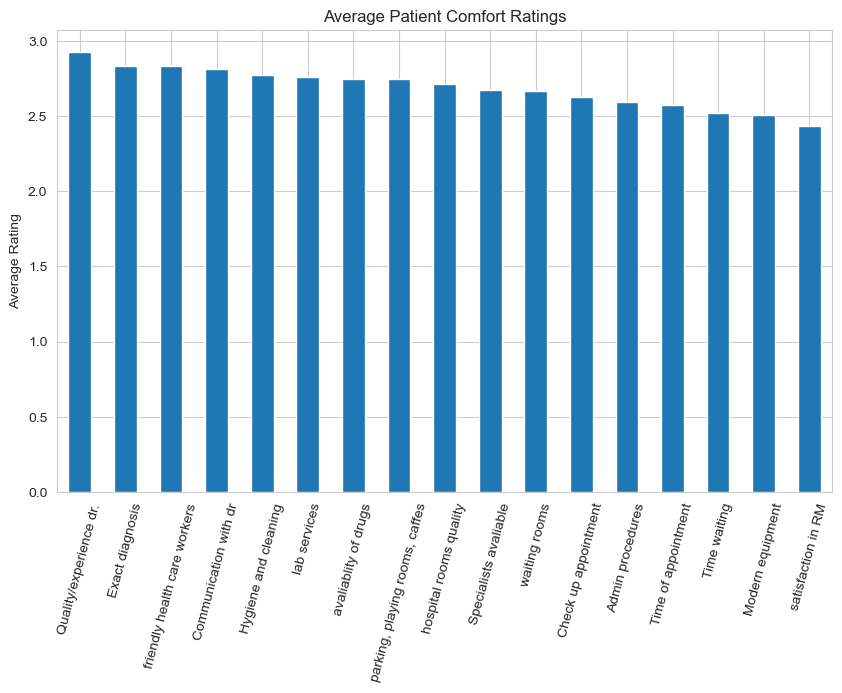

In [89]:
mean_values.plot(kind="bar")

plt.title("Average Patient Comfort Ratings")

plt.ylabel("Average Rating")

plt.xticks(rotation=75)

plt.show()

The bar chart shows the average rating for each patient comfort factor. Higher values indicate better comfort and service quality.

## Distribution of Healthcare Experience Quality

This section shows how patients rated their overall healthcare experience.

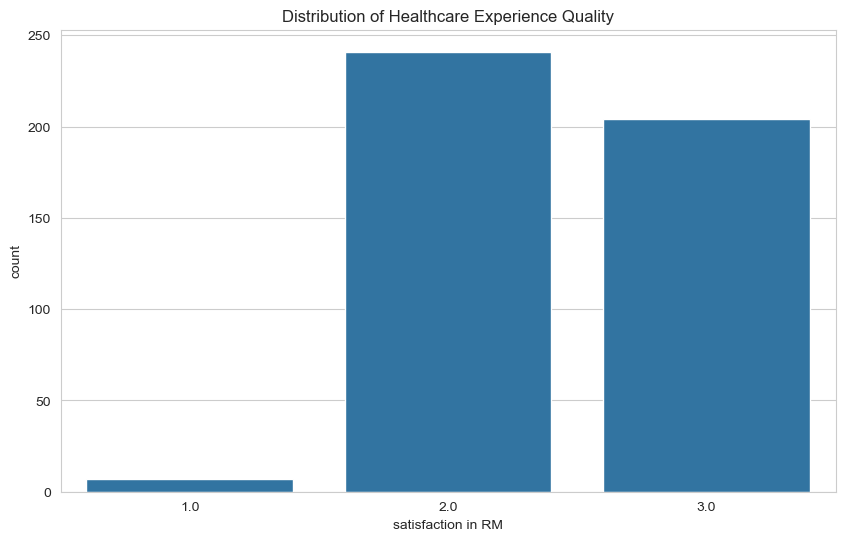

In [90]:
sns.countplot(
    x="satisfaction in RM",
    data=df
)

plt.title("Distribution of Healthcare Experience Quality")

plt.show()

## Interpretation of Distribution

Most patients fall into the Medium and High satisfaction categories.

Very few patients reported Low satisfaction.

This indicates that overall healthcare experience quality is generally positive in this dataset.

## Correlation Analysis

Spearman correlation is used to measure the relationship between patient comfort factors and overall healthcare experience quality.

In [91]:
corr_matrix = df.corr(method="spearman")

# Heatmap

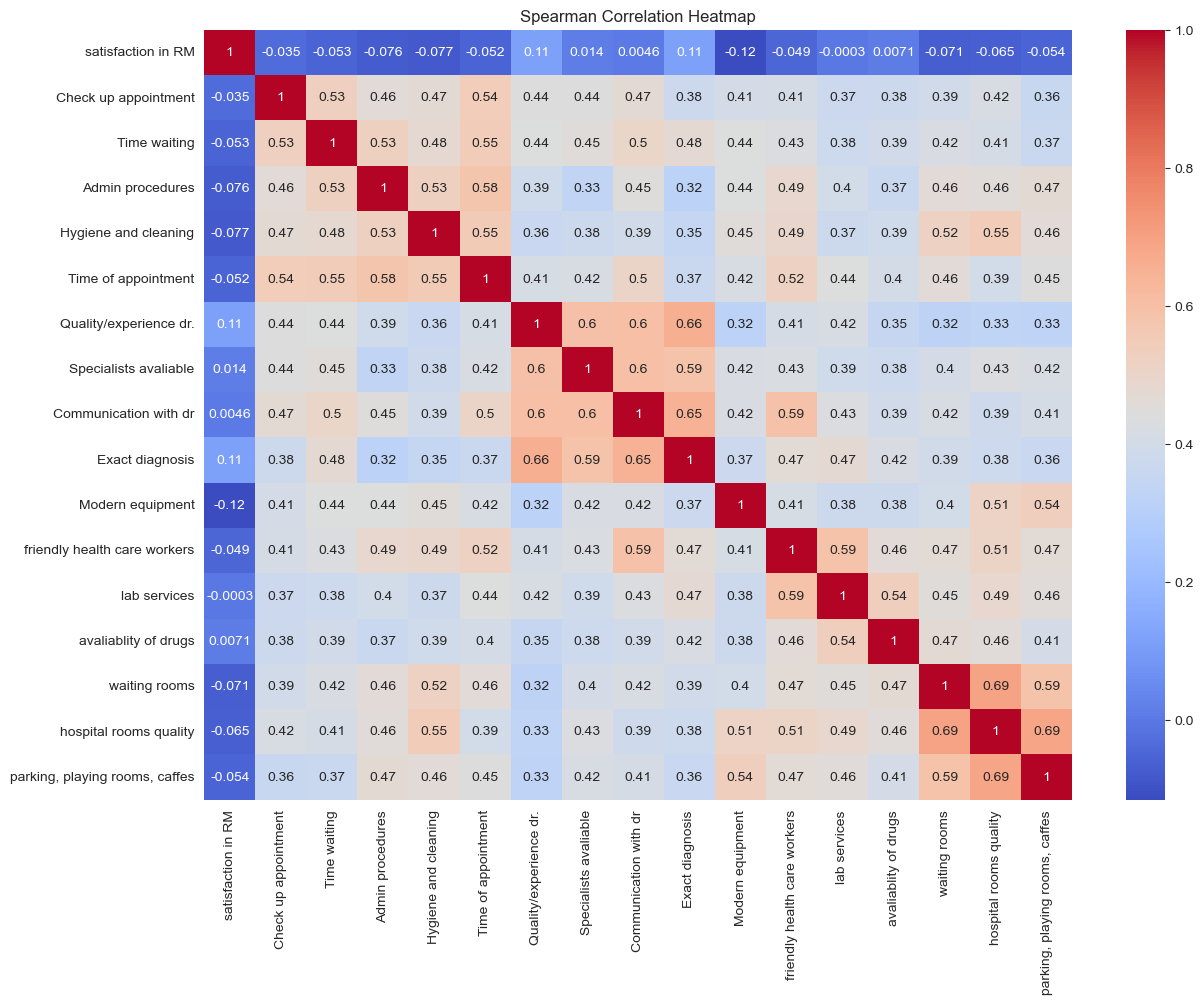

In [92]:
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Spearman Correlation Heatmap")

plt.show()

# Correlation with Satisfaction

In [93]:
corr_with_satisfaction = corr_matrix[
    "satisfaction in RM"
].sort_values(ascending=False)

corr_with_satisfaction

satisfaction in RM                1.000000
Exact diagnosis                   0.113790
Quality/experience dr.            0.112568
Specialists avaliable             0.013827
avaliablity of drugs              0.007144
Communication with dr             0.004551
lab services                     -0.000297
Check up appointment             -0.035325
friendly health care workers     -0.048767
Time of appointment              -0.052005
Time waiting                     -0.053461
parking, playing rooms, caffes   -0.053929
hospital rooms quality           -0.064564
waiting rooms                    -0.070632
Admin procedures                 -0.075889
Hygiene and cleaning             -0.077084
Modern equipment                 -0.115621
Name: satisfaction in RM, dtype: float64

## Key Correlation Findings

The correlation analysis shows that:

Exact diagnosis  
Quality of doctor experience  
Communication with doctor  

have the strongest positive relationships with patient satisfaction.

This suggests that clinical service quality factors have greater influence on healthcare experience than operational factors such as waiting time.

## Grouping Patients by Satisfaction Level

Patients are grouped into Low, Medium, and High satisfaction levels.

In [94]:
df["satisfaction_group"] = df[
    "satisfaction in RM"
].map({
    1: "Low",
    2: "Medium",
    3: "High"
})

In [95]:
df["satisfaction_group"].value_counts()

satisfaction_group
Medium    241
High      204
Low         7
Name: count, dtype: int64

## Comparison of Patient Comfort Across Satisfaction Levels

In [96]:
group_means = df.groupby(
    "satisfaction_group"
).mean()

group_means

,satisfaction in RM,Check up appointment,Time waiting,Admin procedures,Hygiene and cleaning,Time of appointment,Quality/experience dr.,Specialists avaliable,Communication with dr,Exact diagnosis,Modern equipment,friendly health care workers,lab services,avaliablity of drugs,waiting rooms,hospital rooms quality,"parking, playing rooms, caffes"
satisfaction_group,,,,,,,,,,,,,,,,,
High,3.0,2.588235,2.465686,2.480392,2.647059,2.524510,3.142157,2.720588,2.848039,3.039216,2.357843,2.754902,2.759804,2.754902,2.583333,2.622549,2.656863
Low,1.0,3.142857,3.285714,2.714286,2.142857,3.285714,3.285714,2.857143,3.285714,3.142857,2.571429,2.857143,2.714286,2.714286,3.000000,2.285714,2.142857
Medium,2.0,2.643154,2.539419,2.688797,2.896266,2.597510,2.730290,2.630705,2.771784,2.643154,2.630705,2.892116,2.755187,2.738589,2.730290,2.804979,2.834025


Chart

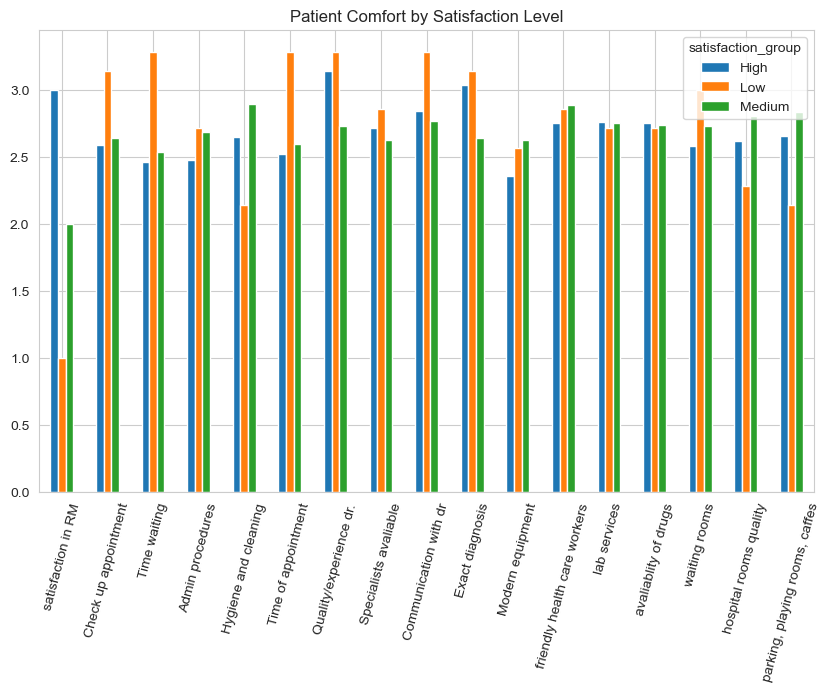

In [97]:
group_means.T.plot(kind="bar")

plt.title("Patient Comfort by Satisfaction Level")

plt.xticks(rotation=75)

plt.show()

Patients with higher satisfaction levels generally report better comfort ratings.

## Inferential Analysis

This section tests whether comfort-related factors have a significant relationship with overall satisfaction.

Hypotheses:

H0: Comfort-related factors have no significant relationship with overall satisfaction.

H1: At least one comfort-related factor has a significant relationship with overall satisfaction.

Decision rule (alpha = 0.05):

- If p-value < 0.05: reject H0 for that factor.
- If p-value >= 0.05: fail to reject H0 for that factor.

Overall decision:

- If at least one factor is significant, reject the global H0.
- If no factors are significant, fail to reject the global H0.

## Spearman Test for All Comfort Factors

In [98]:
target_col = "satisfaction in RM"
exclude_cols = {target_col, "satisfaction_group"}
comfort_cols = [col for col in df.columns if col not in exclude_cols]

spearman_results = []
for col in comfort_cols:
    rho, p_value = spearmanr(df[col], df[target_col])
    spearman_results.append({
        "factor": col,
        "spearman_rho": rho,
        "p_value": p_value,
        "significant": p_value < 0.05
    })

spearman_df = pd.DataFrame(spearman_results).sort_values("p_value")
print("Spearman test results (sorted by p-value):")
display(spearman_df)

sig_count = int(spearman_df["significant"].sum())
total_count = len(spearman_df)

print(f"Significant factors (Spearman, p < 0.05): {sig_count}/{total_count}")
if sig_count > 0:
    print("Overall Spearman decision: Reject global H0.")
else:
    print("Overall Spearman decision: Fail to reject global H0.")

Spearman test results (sorted by p-value):


,factor,spearman_rho,p_value,significant
9,Modern equipment,-0.115621,0.013910,True
8,Exact diagnosis,0.113790,0.015504,True
5,Quality/experience dr.,0.112568,0.016656,True
3,Hygiene and cleaning,-0.077084,0.101687,False
2,Admin procedures,-0.075889,0.107119,False
13,waiting rooms,-0.070632,0.133776,False
14,hospital rooms quality,-0.064564,0.170600,False
15,"parking, playing rooms, caffes",-0.053929,0.252535,False
1,Time waiting,-0.053461,0.256687,False
4,Time of appointment,-0.052005,0.269890,False


Significant factors (Spearman, p < 0.05): 3/16
Overall Spearman decision: Reject global H0.


## Interpretation (Spearman)

This table gives the correlation and p-value for each comfort-related factor against overall satisfaction.

- `significant = True` means that factor is significantly related to satisfaction at alpha = 0.05.
- If at least one factor is significant, reject the global H0.
- If no factors are significant, fail to reject the global H0.

## Kruskal-Wallis Test for All Comfort Factors

This test compares each comfort factor across the three satisfaction groups (1, 2, 3).

In [99]:
target_col = "satisfaction in RM"
exclude_cols = {target_col, "satisfaction_group"}
comfort_cols = [col for col in df.columns if col not in exclude_cols]

kw_results = []
for col in comfort_cols:
    g1 = df[df[target_col] == 1][col]
    g2 = df[df[target_col] == 2][col]
    g3 = df[df[target_col] == 3][col]

    stat, p_value = kruskal(g1, g2, g3)
    kw_results.append({
        "factor": col,
        "kw_statistic": stat,
        "p_value": p_value,
        "significant": p_value < 0.05
    })

kw_df = pd.DataFrame(kw_results).sort_values("p_value")
print("Kruskal-Wallis results (sorted by p-value):")
display(kw_df)

kw_sig_count = int(kw_df["significant"].sum())
kw_total_count = len(kw_df)

print(f"Significant factors (Kruskal-Wallis, p < 0.05): {kw_sig_count}/{kw_total_count}")
if kw_sig_count > 0:
    print("Overall Kruskal-Wallis decision: Reject global H0.")
else:
    print("Overall Kruskal-Wallis decision: Fail to reject global H0.")

Kruskal-Wallis results (sorted by p-value):


,factor,kw_statistic,p_value,significant
5,Quality/experience dr.,7.252200,0.026620,True
8,Exact diagnosis,7.118062,0.028466,True
9,Modern equipment,6.314976,0.042532,True
3,Hygiene and cleaning,5.645327,0.059447,False
15,"parking, playing rooms, caffes",3.930271,0.140137,False
14,hospital rooms quality,3.463539,0.176971,False
2,Admin procedures,2.674423,0.262577,False
1,Time waiting,2.397523,0.301567,False
13,waiting rooms,2.381803,0.303947,False
4,Time of appointment,2.115655,0.347209,False


Significant factors (Kruskal-Wallis, p < 0.05): 3/16
Overall Kruskal-Wallis decision: Reject global H0.


## Final Inferential Conclusion

At alpha = 0.05, inferential tests were performed for all comfort-related factors against overall satisfaction (excluding the derived variable `satisfaction_group`).

- Spearman significant factors: 3/16
- Kruskal-Wallis significant factors: 3/16

Significant factors in both tests were:

- Quality/experience dr.
- Exact diagnosis
- Modern equipment

Therefore, we reject the global null hypothesis (H0) and conclude that comfort-related factors have a statistically significant relationship with overall satisfaction.

At the same time, most factors were not significant, so the effect is concentrated in specific dimensions rather than all comfort variables.

## Predictive Analysis

This section builds machine learning models to predict healthcare experience quality using patient comfort factors.

Define Variables

In [100]:
X = df.drop(
    columns=[
        "satisfaction in RM",
        "satisfaction_group"
    ]
)

y = df["satisfaction in RM"]

Train Test Split

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Logistic Regression

In [102]:
model1 = LogisticRegression(
    max_iter=1000
)

model1.fit(
    X_train,
    y_train
)

pred1 = model1.predict(
    X_test
)

print(
    "Logistic Regression Accuracy:",
    accuracy_score(
        y_test,
        pred1
    )
)

print(
    classification_report(
        y_test,
        pred1
    )
)

Logistic Regression Accuracy: 0.5824175824175825
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         2.0       0.59      0.76      0.66        49
         3.0       0.57      0.39      0.46        41

    accuracy                           0.58        91
   macro avg       0.39      0.38      0.37        91
weighted avg       0.57      0.58      0.56        91



## Model Evaluation — Logistic Regression

The classification report shows the performance of the Logistic Regression model using precision, recall, and F1-score.

These metrics provide a detailed evaluation of how well the model predicts healthcare experience quality.

# Random Forest

In [103]:
model2 = RandomForestClassifier()

model2.fit(
    X_train,
    y_train
)

pred2 = model2.predict(
    X_test
)

print(
    "Random Forest Accuracy:",
    accuracy_score(
        y_test,
        pred2
    )
)

print(
    classification_report(
        y_test,
        pred2
    )
)

Random Forest Accuracy: 0.6373626373626373
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         2.0       0.69      0.71      0.70        49
         3.0       0.66      0.56      0.61        41

    accuracy                           0.64        91
   macro avg       0.45      0.43      0.44        91
weighted avg       0.67      0.64      0.65        91



## Model Evaluation — Random Forest

The classification report shows the predictive performance of the Random Forest model.

Higher precision, recall, and F1-score values indicate better model performance in predicting healthcare experience quality.

In [104]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred1),
        accuracy_score(y_test, pred2)
    ]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.582418
1,Random Forest,0.637363


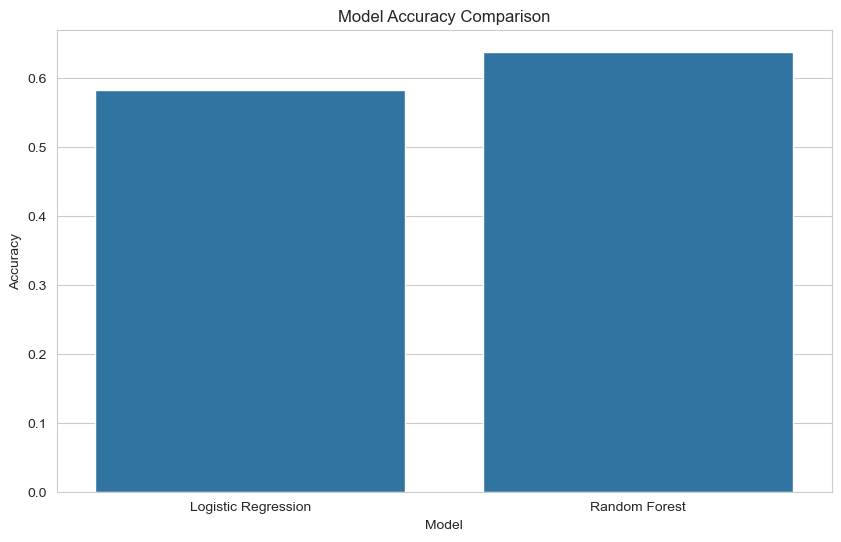

In [105]:
sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")

plt.show()

In [106]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, pred1),
        accuracy_score(y_test, pred2)
    ],
    "Precision (weighted)": [
        precision_score(y_test, pred1, average="weighted", zero_division=0),
        precision_score(y_test, pred2, average="weighted", zero_division=0)
    ],
    "Recall (weighted)": [
        recall_score(y_test, pred1, average="weighted", zero_division=0),
        recall_score(y_test, pred2, average="weighted", zero_division=0)
    ],
    "F1-score (weighted)": [
        f1_score(y_test, pred1, average="weighted", zero_division=0),
        f1_score(y_test, pred2, average="weighted", zero_division=0)
    ]
})

results

,Model,Accuracy,Precision (weighted),Recall (weighted),F1-score (weighted)
0,Logistic Regression,0.582418,0.573696,0.582418,0.564720
1,Random Forest,0.637363,0.665608,0.637363,0.649624


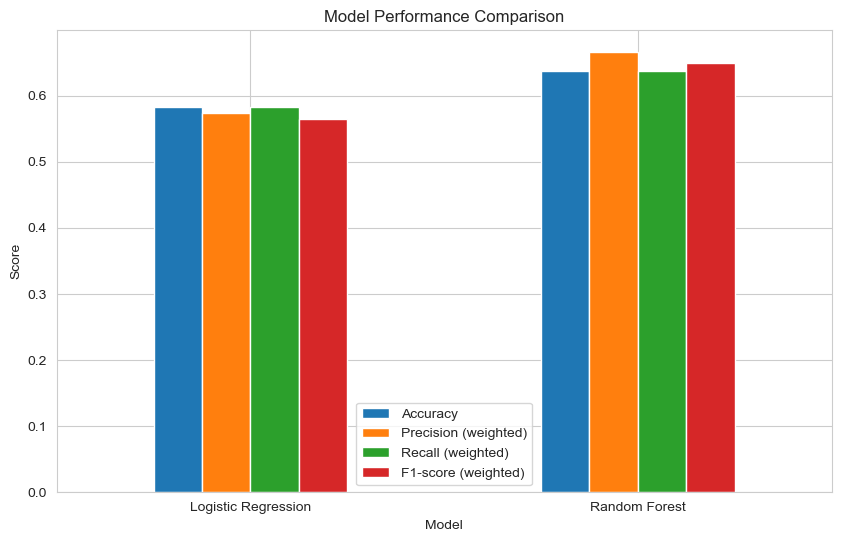

In [107]:
import matplotlib.pyplot as plt

results.set_index("Model")[[
    "Accuracy",
    "Precision (weighted)",
    "Recall (weighted)",
    "F1-score (weighted)"
]].plot(kind="bar", figsize=(10,6))

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

In [108]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model2.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

Quality/experience dr.            0.077599
Specialists avaliable             0.076539
Hygiene and cleaning              0.072563
avaliablity of drugs              0.071970
Modern equipment                  0.069560
Communication with dr             0.063204
Check up appointment              0.062636
Exact diagnosis                   0.062366
Time of appointment               0.058566
friendly health care workers      0.058304
Admin procedures                  0.058027
parking, playing rooms, caffes    0.057636
lab services                      0.056033
Time waiting                      0.054710
hospital rooms quality            0.051982
waiting rooms                     0.048306
dtype: float64

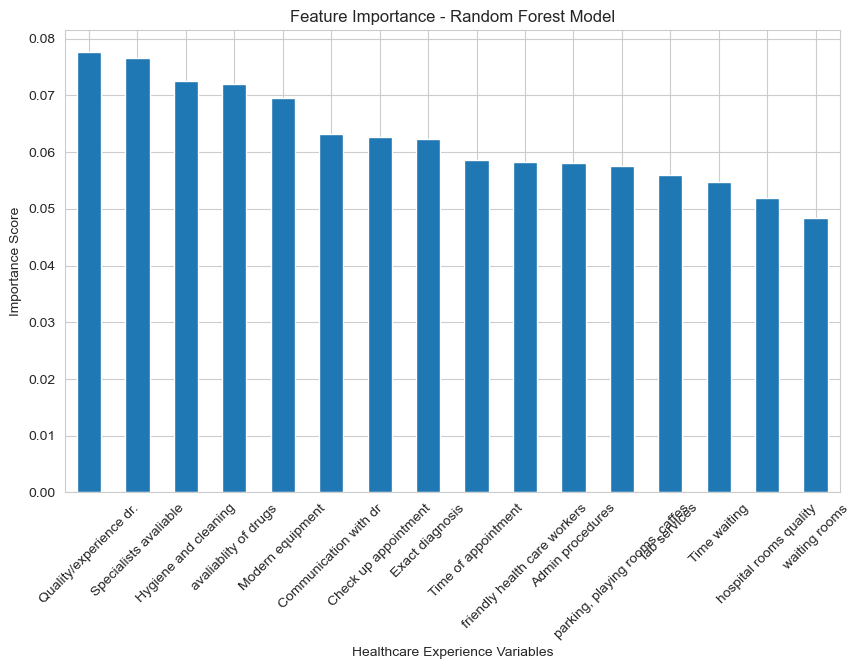

In [109]:
plt.figure(figsize=(10,6))

importance.plot(kind="bar")

plt.title("Feature Importance - Random Forest Model")
plt.xlabel("Healthcare Experience Variables")
plt.ylabel("Importance Score")

plt.xticks(rotation=45)

plt.show()

## Feature Importance Analysis

Feature importance was calculated using the Random Forest model to identify which healthcare experience variables most strongly influence patient satisfaction.

The results show that some variables contribute more significantly to predicting satisfaction than others. Variables with higher importance scores have a greater impact on the model’s predictions.

This analysis supports the statement that healthcare service quality factors play an important role in determining patient satisfaction.

## Predicted vs Actual Comparison

In [110]:
comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Logistic": pred1,
    "Predicted_RandomForest": pred2
})

comparison_df.head(20)

,Actual,Predicted_Logistic,Predicted_RandomForest
0,2.0,2.0,2.0
1,2.0,2.0,2.0
2,2.0,2.0,2.0
3,3.0,2.0,3.0
4,2.0,2.0,2.0
5,3.0,2.0,2.0
6,2.0,2.0,2.0
7,3.0,2.0,2.0
8,3.0,3.0,3.0
9,2.0,2.0,3.0


## Model Evaluation Using Test Data

A comparison between actual and predicted satisfaction values was performed using the test dataset.

The results demonstrate that the models are able to predict patient satisfaction with reasonable accuracy. This confirms that the relationship between healthcare experience variables and patient satisfaction is learnable and generalizable.

## Interpretation of Model Comparison

The Random Forest model achieved slightly higher accuracy than the Logistic Regression model.

This indicates that Random Forest provides better prediction performance for healthcare experience quality in this dataset.

However, the difference in accuracy is small, suggesting that both models perform similarly.

# Confusion Matrix

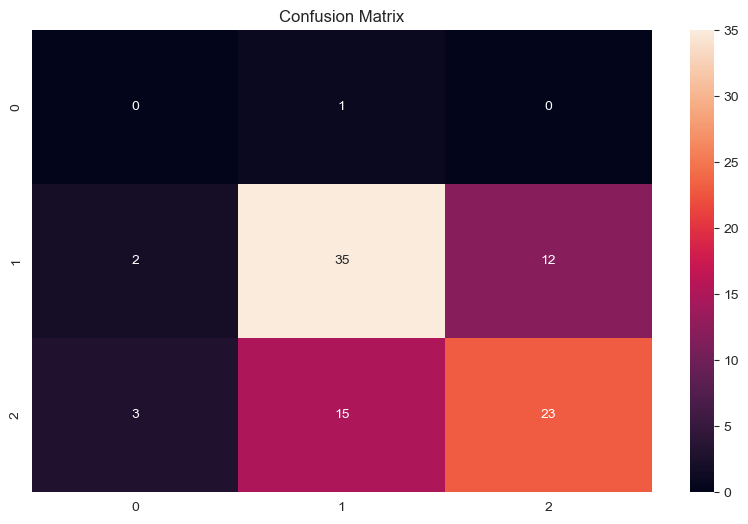

In [111]:
cm = confusion_matrix(
    y_test,
    pred2
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")

plt.show()

## Interpretation of Confusion Matrix

The confusion matrix shows how well the model correctly predicts each satisfaction category.

Most predictions are correctly classified in the Medium and High satisfaction groups.

Some misclassification occurs between Medium and High categories, indicating moderate prediction accuracy.

# Feature Importance

In [112]:
importance = pd.Series(
    model2.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importance

Quality/experience dr.            0.077599
Specialists avaliable             0.076539
Hygiene and cleaning              0.072563
avaliablity of drugs              0.071970
Modern equipment                  0.069560
Communication with dr             0.063204
Check up appointment              0.062636
Exact diagnosis                   0.062366
Time of appointment               0.058566
friendly health care workers      0.058304
Admin procedures                  0.058027
parking, playing rooms, caffes    0.057636
lab services                      0.056033
Time waiting                      0.054710
hospital rooms quality            0.051982
waiting rooms                     0.048306
dtype: float64

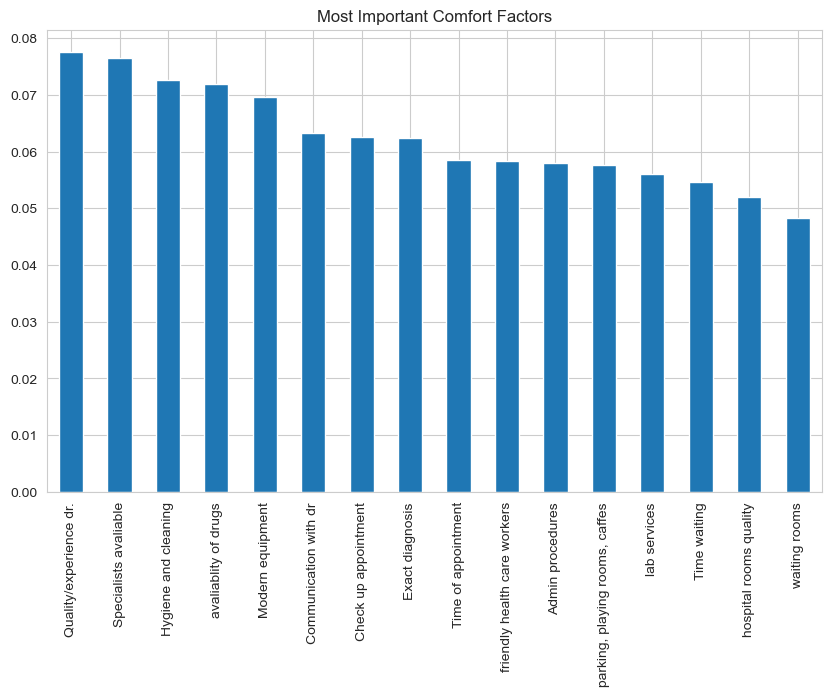

In [113]:
importance.plot(kind="bar")

plt.title("Most Important Comfort Factors")

plt.show()

In [114]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Logistic": pred1,
    "Predicted_RandomForest": pred2
})

comparison_df.head(20)

,Actual,Predicted_Logistic,Predicted_RandomForest
0,2.0,2.0,2.0
1,2.0,2.0,2.0
2,2.0,2.0,2.0
3,3.0,2.0,3.0
4,2.0,2.0,2.0
5,3.0,2.0,2.0
6,2.0,2.0,2.0
7,3.0,2.0,2.0
8,3.0,3.0,3.0
9,2.0,2.0,3.0


## Interpretation of Feature Importance

The feature importance analysis shows that the most influential factors affecting healthcare experience quality are:

Doctor experience quality  
Availability of drugs  
Hygiene and cleaning  
Availability of specialists  
Accuracy of diagnosis  

These results indicate that medical service quality plays a major role in determining patient satisfaction.

## Conclusion

This study analyzed the influence of comfort-related factors on overall healthcare satisfaction.

Inferential analysis across all comfort factors (not only time waiting) identified statistically significant relationships for a subset of factors at alpha = 0.05.

Therefore, the global null hypothesis (H0) is rejected, indicating that comfort-related factors do have a significant relationship with overall satisfaction.

At the factor level, not all variables were significant, which suggests that some comfort dimensions have stronger effects than others.

The predictive models demonstrated moderate performance in predicting healthcare experience quality, with Random Forest slightly outperforming Logistic Regression.

## Recommendations

Healthcare providers should prioritize factors that were statistically supported in inferential analysis and predictive analysis:

Quality and experience of doctors  
Accuracy of diagnosis  
Modern equipment and service infrastructure  

Secondary improvements can still target communication, hygiene, and medicine availability, but these were not statistically significant in the inferential tests of this dataset.

Focusing first on the strongest factors is more likely to improve overall patient satisfaction and healthcare experience quality.